In [18]:
import sys
print(sys.executable)

E:\anconda\envs\jupyter_env\python.exe


In [19]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.Collecting scikit-learn
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.9 MB 1.7 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/8.9 MB 1.9 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.9 MB 1.9 MB/s eta 0:00:04
   --------- ------------------------------ 2.1/8.9 MB 1.9 MB/s eta 0:00:04
   ---------- ----------------------------- 2.4/8.9 MB 2.0 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/8.9 MB 1.9 MB/s eta 0:00:04
   -------------- ------------------------- 3.1/8.9 MB 1.9 MB/s eta 0:00:04
   ---------------- ----------------------- 3.7/8.9 MB 1.9 MB/s eta 0:00:03
   ------------------ --------------------- 4.2/8.9 MB 1.9 MB/s eta 0:00:03
   -------------------- ------------------- 4.5/8.9 MB 1.9 MB/s eta 0:00:03
   ----------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline

import seaborn as sns

#This will hide some unnecessary warning messages so our notebook looks clean
import warnings
warnings.filterwarnings('ignore')

In [2]:
data_url = "https://raw.githubusercontent.com/avikumart/Road-Traffic-Severity-Classification-Project/main/RTA%20Dataset.csv"
df = pd.read_csv(data_url)
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [3]:
print(df.shape)


(12316, 32)


In [4]:
df.columns


Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')

In [5]:
# This is our target column - the things  we want to predict
df['Accident_severity'].value_counts(normalize=True)

Accident_severity
Slight Injury     0.845648
Serious Injury    0.141523
Fatal injury      0.012829
Name: proportion, dtype: float64

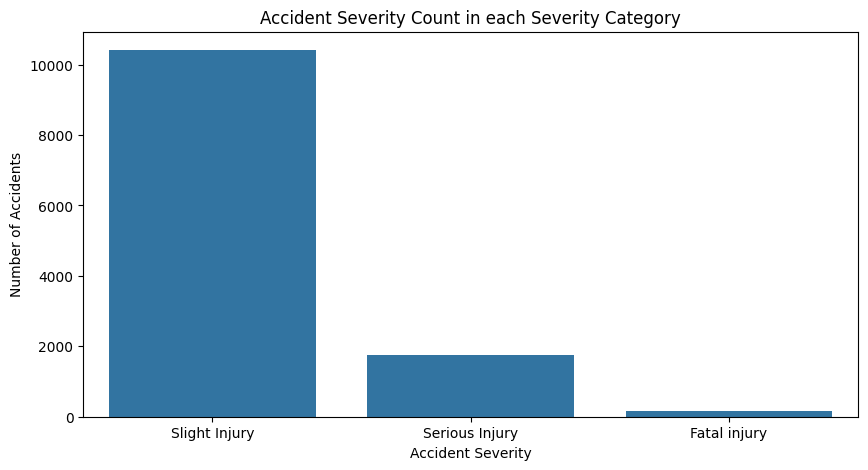

In [6]:
#Lets Draw a bar chart to visualize the target column
plt.figure(figsize=(10,5))
sns.countplot(x='Accident_severity',data=df,order=df['Accident_severity'].value_counts().index)
plt.title('Accident Severity Count in each Severity Category')
plt.xlabel('Accident Severity')
plt.ylabel("Number of Accidents")

plt.show()

In [7]:
# Lets check how many missing(empty) values are present in each column
df.isnull().sum()

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

In [8]:
from pandas._libs import missing
# we only show columns that actually have missing values,sorted from highest to lowest
missing_values = df.isnull().sum()

data = missing_values[missing_values > 0].sort_values(ascending=False)
print(data)

Defect_of_vehicle          4427
Service_year_of_vehicle    3928
Work_of_casuality          3198
Fitness_of_casuality       2635
Type_of_vehicle             950
Types_of_Junction           887
Driving_experience          829
Educational_level           741
Vehicle_driver_relation     579
Owner_of_vehicle            482
Lanes_or_Medians            385
Vehicle_movement            308
Area_accident_occured       239
Road_surface_type           172
Type_of_collision           155
Road_allignment             142
dtype: int64


In [9]:
# First, lets separate column names into 2 lists: categorical and numerical

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

print("Categorical Columns:",categorical_cols,"\n\n")
print("\nNumerical Columns:",numerical_cols)


Categorical Columns: ['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity'] 



Numerical Columns: ['Number_of_vehicles_involved', 'Number_of_casualties']


In [10]:
# Fill missing values in Categorical columns 
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

  # Fill missing values in NUMERICAL columns with the median values of that column
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Lets's double check - there should be zero missing values now
print("Total missing values remaining:\n",df.isnull().sum())


Total missing values remaining:
 Time                           0
Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Educational_level              0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Service_year_of_vehicle        0
Defect_of_vehicle              0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Casualty_class                 0
Sex_of_casualty                0
Age_band_of_casualty           0
Casualty_severity              0
Work_of_casuality              0
Fitness_of_casuality           0
Pedestrian

In [11]:
# Let's look at the atime column first
df['Time'].head()

0    17:02:00
1    17:02:00
2    17:02:00
3     1:06:00
4     1:06:00
Name: Time, dtype: object

In [14]:
# pd.to_datetime() converts the text into a proper time format that python understands
#.dt.hour extracts only the hour part (a number from 0 to 23)

df['Hour']= pd.to_datetime(df['Time'],format = '%H:%M:%S').dt.hour

# now that we have extracted the hour , we dont need the original time column anymore
df = df.drop(columns=['Time'])

#lets check our new column
df[['Hour']].head()

,Hour
0,17
1,17
2,17
3,1
4,1


In [15]:
df['Hour'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 12316 entries, 0 to 12315
Series name: Hour
Non-Null Count  Dtype
--------------  -----
12316 non-null  int32
dtypes: int32(1)
memory usage: 48.2 KB


In [16]:
df.head()

,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour
0,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,...,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Moving Backward,Slight Injury,17
1,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,...,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Overtaking,Slight Injury,17
2,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,Unknown,No defect,...,Driver or rider,Male,31-50,3,Driver,Unknown,Not a Pedestrian,Changing lane to the left,Serious Injury,17
3,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Unknown,No defect,...,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury,1
4,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Unknown,Owner,5-10yrs,No defect,...,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Overtaking,Slight Injury,1


In [21]:
# these are the columns we will use as input features (things we know about the  accident scene)

feature_cols = [
    'Day_of_week',
    'Age_band_of_driver',
    'Sex_of_driver',
    'Educational_level',
    'Driving_experience',
    'Type_of_vehicle',
    'Area_accident_occured',
    'Lanes_or_Medians',
    'Road_allignment',
    'Types_of_Junction',
    'Road_surface_type',
    'Road_surface_conditions',
    'Light_conditions',
    'Weather_conditions',
    'Type_of_collision',
    'Number_of_vehicles_involved',
    'Number_of_casualties',
    'Vehicle_movement',
    'Cause_of_accident',
    'Hour'
]

# this is our target column (what we want to predict)
target_col ='Accident_severity'

# lets create a smaller, cleaner dataframe with only the columns we need 
df_model =  df[feature_cols + [target_col]].copy()

df_model.head()

,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Driving_experience,Type_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,...,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Cause_of_accident,Hour,Accident_severity
0,Monday,18-30,Male,Above high school,1-2yr,Automobile,Residential areas,Unknown,Tangent road with flat terrain,No junction,...,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,Moving Backward,17,Slight Injury
1,Monday,31-50,Male,Junior high school,Above 10yr,Public (> 45 seats),Office areas,Undivided Two way,Tangent road with flat terrain,No junction,...,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,Overtaking,17,Slight Injury
2,Monday,18-30,Male,Junior high school,1-2yr,Lorry (41?100Q),Recreational areas,other,Unknown,No junction,...,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Changing lane to the left,17,Serious Injury
3,Sunday,18-30,Male,Junior high school,5-10yr,Public (> 45 seats),Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,...,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Changing lane to the right,1,Slight Injury
4,Sunday,18-30,Male,Junior high school,2-5yr,Unknown,Industrial areas,other,Tangent road with flat terrain,Y Shape,...,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Overtaking,1,Slight Injury


### Work of Label-Encoder 
1. extract unique values
2. 2. sort the values
   3. 3. assign no to the vlues
      4. 4. replace


In [22]:
# Import the LabelEncoder tool from scikit-Learn
from sklearn.preprocessing import LabelEncoder

#we will create one encoder for Each categorical column, and store it in a dictionary
# so that we can remember how each column was encoded (useful if we want o decode later)
label_encoder = {}

# Find which columns (in our smaller df_model) are still text (categorical)
categorical_features = df_model.select_dtypes(include='object').columns.tolist()
print(categorical_features)


['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Driving_experience', 'Type_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Cause_of_accident', 'Accident_severity']


In [23]:
# Remove the target column from this list - we will encode it separately
categorical_features.remove(target_col)

print("Categorical feature columns to encode:",categorical_features)

Categorical feature columns to encode: ['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Driving_experience', 'Type_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Cause_of_accident']


In [27]:
# now lets encode each categorical feature column, one by one

for col in categorical_features:
  le = LabelEncoder()                           # create a new encoder
  df_model[col] = le.fit_transform(df_model[col]) # convert text to numbers
  label_encoder[col] = le                         # save the encoder for this column

df_model.head()

,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Driving_experience,Type_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,...,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Cause_of_accident,Hour,Accident_severity
0,1,0,1,0,0,0,9,5,5,1,...,0,3,2,3,2,2,2,9,17,2
1,1,1,1,4,3,11,6,4,5,1,...,0,3,2,8,2,2,2,16,17,2
2,1,0,1,4,0,5,1,6,9,1,...,0,3,2,2,2,2,2,0,17,1
3,3,0,1,4,2,11,6,6,6,7,...,0,0,2,8,2,2,2,1,1,2
4,3,0,1,4,1,17,4,6,5,7,...,0,0,2,8,2,2,2,16,1,2


In [28]:
label_encoder

{'Day_of_week': LabelEncoder(),
 'Age_band_of_driver': LabelEncoder(),
 'Sex_of_driver': LabelEncoder(),
 'Educational_level': LabelEncoder(),
 'Driving_experience': LabelEncoder(),
 'Type_of_vehicle': LabelEncoder(),
 'Area_accident_occured': LabelEncoder(),
 'Lanes_or_Medians': LabelEncoder(),
 'Road_allignment': LabelEncoder(),
 'Types_of_Junction': LabelEncoder(),
 'Road_surface_type': LabelEncoder(),
 'Road_surface_conditions': LabelEncoder(),
 'Light_conditions': LabelEncoder(),
 'Weather_conditions': LabelEncoder(),
 'Type_of_collision': LabelEncoder(),
 'Vehicle_movement': LabelEncoder(),
 'Cause_of_accident': LabelEncoder()}

In [32]:
# Now lets encode the target column (Accident_serevity) separately
#we use a different encoder so we can easily convert numbers back to labels later

target_encoder = LabelEncoder()
df_model[target_col] = target_encoder.fit_transform(df_model[target_col])

for i, class_name in enumerate (target_encoder.classes_):
  print(f"{i}    ->   {class_name}")

0    ->   0
1    ->   1
2    ->   2


In [33]:
# X contains all our feature columns (everything except the target)
X = df_model[feature_cols]

# y contains only the target column (what we want to predict )
y = df_model[target_col]

print("Shape of X (feature):",X.shape)
print("Shape of y (target):",y.shape)

Shape of X (feature): (12316, 20)
Shape of y (target): (12316,)


In [ ]:
from sklearn.model_selection import train_test_split
 X_train, X_test, y_train, y_test  